# Semantic Segmentation: Custom CNN U-Net & Extensive Grid Search
## Final Exam Project - Fully Custom Architecture

**Objective:**
Develop a high-performance semantic segmentation model using a **Custom CNN Architecture** (no pre-trained backbone) and optimize it via an extensive **Hyperparameter Grid Search**.

**Key Technical Decisions:**
1.  **Custom CNN U-Net:** We build the encoder and decoder from scratch. This gives us full control over layer depth, filter sizes, and feature extraction mechanisms, avoiding the "black box" nature of transfer learning constants.
2.  **Upsampling Strategy:** We strictly use **Bilinear Upsampling + Conv2D** (instead of Transposed Convolution) to prevent checkerboard artifacts in the output masks.
3.  **Hyperparameter Search:** We now search over **6 dimensions**:
    *   **Learning Rate:** Step size for optimizer.
    *   **Dropout Rate:** Regularization intensity.
    *   **Focal Loss Gamma ($\gamma$):** Focus on hard-to-classify pixels.
    *   **Start Filters:** Capacity of the network (width).
    *   **Kernel Size:** Receptive field size ($3\times3$ vs $5\times5$).
    *   **Pooling Method:** Downsampling strategy (**Max** vs **Average**).


# Project Report: Semantic Segmentation on Aerial Imagery

**Course:** MATH605 - Deep Learning Theory

**Instructor:** Gönenç ONAY

**Student:** Duygu ÇAKIR

## 1. Objective and Scope

The primary goal of this project is to perform semantic segmentation on aerial imagery to identify specific land features. Unlike standard approaches that rely on pre-trained backbones (Transfer Learning), this project focuses on the theoretical construction of a **fully custom CNN / U-Net architecture**. The emphasis is placed on understanding the internal dynamics of CNNs and their performance through a systematic **Grid Search** hyperparameter searching process.

---

## 2. Methodology and Workflow

### 2.1. Data Pipeline

* **Data Preprocessing:** Images and masks were normalized to the  range and resized to a consistent  resolution.
* **GPU-Accelerated Augmentation:** To mitigate CPU bottlenecks, an augmentation pipeline was integrated directly into the model using `tf.keras.layers`. This allows spatial transformations like `RandomFlip`, `RandomRotation`, and `RandomZoom` to be executed on the GPU in parallel, otherwise it is slower.
* **tf.data Optimization:** Implemented `prefetch(AUTOTUNE)` to overlap data preparation with model execution, ensuring maximum hardware utilization.

### 2.2. Architectural Design (Custom CNN / U-Net)

The architecture follows the principles of the U-Net, designed with specific theoretical considerations:

* **Encoder:** A series of convolutional blocks for hierarchical feature extraction.
* **Decoder & Upsampling Strategy:** To avoid the common "checkerboard artifacts" associated with Transposed Convolutions, this project utilizes **Bilinear Upsampling followed by Conv2D** layers for a smoother reconstruction of the segmentation masks.

---

## 3. Hyperparameter Optimization (Grid Search)

A multi-dimensional grid search was conducted to find the optimal configuration. Since it takes a lot of time on the searching process, a **Skip Logic** was implemented to allow the search to resume from the last saved state in case of interruptions.

* **Dimensions Searched:** Learning Rate, Dropout Rate, Start Filters, Kernel Size, and Pooling Type (Max vs. Average). (I have started with max pooling in the grid search, however, almost every time average pooling performed better, hence, removed the max pooling option. But it is applicable.)
* **Persistence:** Every iteration's results were logged to a CSV for post-search analysis and visualization.

---

## 4. Theory-Based Loss and Evaluation

* **Focal Loss:** Chosen to address the class imbalance inherent in aerial segmentation. It refocuses training on hard-to-classify pixels by modifying the standard cross-entropy loss.
* **Evaluation Metrics:** Beyond accuracy, the model was evaluated using the **Dice Coefficient** and **Intersection over Union (IoU)**, which are used for measuring segmentation overlap accuracy.

---

## 5. Conclusion and Key Learnings

This project served as a practical application of Deep Learning Theory. Key takeaways include:

1. **Architectural Control:** Building a custom CNN (U-Net) provided deep insights into how filter depth and kernel sizes impact the receptive field and feature resolution.
2. **Efficiency Matters:** Moving data augmentation to the GPU significantly reduced training time per epoch, still it is not enough, but an important step.
3. **Hyperparameter Impact:** Grid search revealed that the interaction between Learning Rate and Dropout is critical for stable convergence in segmentation tasks. Random Search is a better option for hyperparameter optimization, but it is not implemented in this project.

---

### Project Files

* `best_model.keras`: The final optimized model weights.
* `hyperparameter_search_results.csv`: Comprehensive log of the optimization process.



In [1]:
!pip install -r requirements.txt

In [2]:
import os
import glob
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
import albumentations as A
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, MaxPool2D, AveragePooling2D, Concatenate, Input, Dropout, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import backend as K
import itertools

# Configuration
IMG_HEIGHT = 256
IMG_WIDTH = 256
PATCH_SIZE = 256
STRIDE = 128 
SEED = 42
BATCH_SIZE = 4
TRAIN_REPEAT_FACTOR = 15 # Oversample training data 15x

IMAGE_DIR = "images/"
MASK_DIR = "labels/"

print(f"TensorFlow Version: {tf.__version__}")

/Users/dc/miniconda3/envs/cwq/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TensorFlow Version: 2.20.0


### 1. Data Loading & Preprocessing
**Dataset Expansion Strategy:**
Since the dataset is very small (24 images), training on just 19 images per epoch (with batch size 4 -> 5 steps) is unstable.
To fix this, we **oversample** the training patches by including each patch `50` times in the training list.
Combined with **On-the-Fly Augmentation**, this ensures the model sees 50 *different* variations of each original image per epoch.


In [3]:
def sort_paths(paths):
    return sorted(paths, key=lambda x: os.path.basename(x))

def load_image_paths(image_dir, mask_dir):
    image_paths = sort_paths(glob.glob(os.path.join(image_dir, "*.png")))
    mask_paths = sort_paths(glob.glob(os.path.join(mask_dir, "*.png")))
    return np.array(image_paths), np.array(mask_paths)

def patchify_with_overlap(img, patch_size, stride):
    patches = []
    h, w = img.shape[:2]
    if h < patch_size or w < patch_size:
        pad_h = max(0, patch_size - h)
        pad_w = max(0, patch_size - w)
        img = np.pad(img, ((0, pad_h), (0, pad_w), (0, 0)) if len(img.shape)==3 else ((0, pad_h), (0, pad_w)), mode='reflect')
        h, w = img.shape[:2]
    for i in range(0, h - patch_size + 1, stride):
        for j in range(0, w - patch_size + 1, stride):
            patch = img[i:i+patch_size, j:j+patch_size]
            patches.append(patch)
    if not patches: patches.append(img)
    return patches

def process_dataset_from_paths(img_paths, mask_paths, repeat_factor=1):
    X, Y = [], []
    for img_path, mask_path in zip(img_paths, mask_paths):
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        img_patches = patchify_with_overlap(img, PATCH_SIZE, STRIDE)
        mask_patches = patchify_with_overlap(mask, PATCH_SIZE, STRIDE)
        
        # Add copies based on repeat_factor
        for _ in range(repeat_factor):
            X.extend(img_patches)
            Y.extend(mask_patches)
    
    X = np.array(X).astype(np.float32) / 255.0
    Y = np.array(Y).astype(np.float32) / 255.0
    Y = np.expand_dims(Y, axis=-1)
    Y = (Y > 0.5).astype(np.float32)
    return X, Y

# 1. Load & Split
all_img_paths, all_mask_paths = load_image_paths(IMAGE_DIR, MASK_DIR)
train_paths, val_paths, train_mask_paths, val_mask_paths = train_test_split(
    all_img_paths, all_mask_paths, test_size=0.2, random_state=SEED, shuffle=True
)

# 2. Patchify (With Oversampling for Train)
X_train, Y_train = process_dataset_from_paths(train_paths, train_mask_paths, repeat_factor=TRAIN_REPEAT_FACTOR)
X_val, Y_val = process_dataset_from_paths(val_paths, val_mask_paths, repeat_factor=1) # No repeat for Val

print("=" * 40)
print(f"DATASET REPORT (After Expansion)")
print("=" * 40)
print(f"Original Images:       {len(all_img_paths)}")
print(f"  - Training Images:   {len(train_paths)}")
print(f"  - Validation Images: {len(val_paths)}")
print("-" * 40)
print(f"Effective Training Data (Oversampled {TRAIN_REPEAT_FACTOR}x):")
print(f"  - Patches:           {len(X_train)}  <-- These will be augmented on-the-fly!")
print(f"Effective Validation Data (Original):")
print(f"  - Patches:           {len(X_val)}")
print("=" * 40)

DATASET REPORT (After Expansion)
Original Images:       24
  - Training Images:   19
  - Validation Images: 5
----------------------------------------
Effective Training Data (Oversampled 15x):
  - Patches:           285  <-- These will be augmented on-the-fly!
Effective Validation Data (Original):
  - Patches:           5


### 2. Albumentations (Simplified)

In [4]:
def get_aug_pipeline():
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.ShiftScaleRotate(scale_limit=0.1, rotate_limit=15, shift_limit=0.1, p=0.5, border_mode=0),
        A.RandomResizedCrop(size=(IMG_HEIGHT, IMG_WIDTH), scale=(0.8, 1.0), p=0.5),
        A.GaussNoise(p=0.2),
        A.OneOf([A.CLAHE(p=1), A.RandomBrightnessContrast(p=1), A.RandomGamma(p=1)], p=0.9),
        A.OneOf([A.Sharpen(p=1), A.Blur(blur_limit=3, p=1), A.MotionBlur(blur_limit=3, p=1)], p=0.9),
    ])

pipeline = get_aug_pipeline()

def aug_fn(image, mask):
    data = pipeline(image=image, mask=mask)
    return data['image'].astype(np.float32), data['mask'].astype(np.float32)

def process_data_aug(image, mask):
    aug_img, aug_mask = tf.numpy_function(func=aug_fn, inp=[image, mask], Tout=[tf.float32, tf.float32])
    aug_img.set_shape((IMG_HEIGHT, IMG_WIDTH, 3))
    aug_mask.set_shape((IMG_HEIGHT, IMG_WIDTH, 1))
    return aug_img, aug_mask

from tensorflow.keras import layers

# Define augmentation as a Keras Layer model
def get_augmentation_model():
    return tf.keras.Sequential([
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.04), # Approx 15 degrees
        layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
        layers.RandomZoom(height_factor=(-0.2, 0.0)), # Scale 0.8 to 1.0
        # Brightness/Contrast can be added here in TF 2.9+ 
        # layers.RandomBrightness(factor=0.2),
    ])

augmentation_model = get_augmentation_model()

def create_tf_dataset(X, Y, is_training=False):
    ds = tf.data.Dataset.from_tensor_slices((X, Y))
    
    if is_training:
        ds = ds.shuffle(1000)
    
    # Batch size should be a power of 2 for optimal GPU utilization
    ds = ds.batch(BATCH_SIZE)
    
    # Prefetching overlaps the preprocessing and model execution of a training step.
    # While the model is executing training step s, the input pipeline is reading data for step s+1.
    ds = ds.prefetch(buffer_size=tf.data.AUTOTUNE)
    return ds

# Update your training calls
train_ds = create_tf_dataset(X_train, Y_train, is_training=True)
val_ds = create_tf_dataset(X_val, Y_val, is_training=False)


/Users/dc/miniconda3/envs/cwq/lib/python3.13/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


### 2. Custom CNN (U-Net) Architecture
We define a flexible U-Net generator function `build_custom_unet` that accepts architecture hyperparameters (`start_filters`, `kernel_size`, `pooling_type`) to dynamically construct the model.


In [5]:
def conv_block(input, num_filters, kernel_size, dropout_rate):
    x = Conv2D(num_filters, kernel_size, padding="same")(input)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Conv2D(num_filters, kernel_size, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    if dropout_rate > 0:
        x = Dropout(dropout_rate)(x)
    return x

def encoder_block(input, num_filters, kernel_size, dropout_rate, pooling_type='max'):
    x = conv_block(input, num_filters, kernel_size, dropout_rate)
    if pooling_type == 'max':
        p = MaxPool2D((2, 2))(x)
    else:
        p = AveragePooling2D((2, 2))(x)
    return x, p

def decoder_block(input, skip_features, num_filters, kernel_size, dropout_rate):
    x = UpSampling2D(size=(2, 2), interpolation='bilinear')(input)
    x = Concatenate()([x, skip_features])
    x = conv_block(x, num_filters, kernel_size, dropout_rate)
    return x

def build_custom_unet(input_shape=(256, 256, 3), start_filters=16, kernel_size=(3, 3), dropout_rate=0.1, pooling_type='max', augment=False):
    inputs = Input(input_shape)
    x = inputs

    # GPU-Based Augmentation (Active only during training)
    if augment:
        x = layers.RandomFlip("horizontal_and_vertical")(x)
        x = layers.RandomRotation(0.04)(x)
        x = layers.RandomZoom(height_factor=(-0.2, 0.0))(x)

    # Dynamic Encoder
    s1, p1 = encoder_block(x, start_filters, kernel_size, dropout_rate, pooling_type)
    s2, p2 = encoder_block(p1, start_filters * 2, kernel_size, dropout_rate, pooling_type)
    s3, p3 = encoder_block(p2, start_filters * 4, kernel_size, dropout_rate, pooling_type)
    s4, p4 = encoder_block(p3, start_filters * 8, kernel_size, dropout_rate, pooling_type)

    # Bridge
    b1 = conv_block(p4, start_filters * 16, kernel_size, dropout_rate)

    # Dynamic Decoder
    d1 = decoder_block(b1, s4, start_filters * 8, kernel_size, dropout_rate)
    d2 = decoder_block(d1, s3, start_filters * 4, kernel_size, dropout_rate)
    d3 = decoder_block(d2, s2, start_filters * 2, kernel_size, dropout_rate)
    d4 = decoder_block(d3, s1, start_filters, kernel_size, dropout_rate)

    # Output
    outputs = Conv2D(1, 1, padding="same", activation="sigmoid")(d4)

    return Model(inputs, outputs, name="Custom_UNet")

def focal_loss(gamma=2., alpha=.25):
    def focal_loss_fixed(y_true, y_pred):
        epsilon = K.epsilon()
        pt_1 = K.clip(tf.where(tf.equal(y_true, 1), y_pred, tf.ones_like(y_pred)), epsilon, 1. - epsilon)
        pt_0 = K.clip(tf.where(tf.equal(y_true, 0), y_pred, tf.zeros_like(y_pred)), epsilon, 1. - epsilon)
        return -K.mean(alpha * K.pow(1. - pt_1, gamma) * K.log(pt_1)) - K.mean((1 - alpha) * K.pow(pt_0, gamma) * K.log(1. - pt_0))
    return focal_loss_fixed

def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def iou_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

### 3. Extensive Hyperparameter Grid Search
We will iterate through combinations to find the best configuration.


In [6]:
import os
import pandas as pd
import itertools

# File to store results persistently
results_file = 'hyperparameter_search_results.csv'

# Expanded Hyperparameter Grid
param_grid = {
    'learning_rate': [1e-2, 1e-3, 1e-4],
    'dropout_rate': [0.1, 0.3, 0.5],
    'gamma': [2.0],
    'start_filters': [32, 64],
    'kernel_size': [(2, 2), (3, 3)],
    'pooling_type': ['avg']
}

keys, values = zip(*param_grid.items())
combinations = list(itertools.product(*values))

print(f"Starting Hyperparameter Search over {len(combinations)} combinations...")

for i, v in enumerate(combinations):
    params = dict(zip(keys, v))
    
    # --- SKIP LOGIC ---
    if os.path.exists(results_file):
        existing_df = pd.read_csv(results_file)
        # Check if this specific combination already exists in the CSV
        # We convert params to strings for comparison to handle tuples like kernel_size
        match = existing_df.copy()
        for k, val in params.items():
            match = match[match[k].astype(str) == str(val)]
        
        if not match.empty:
            print(f"[{i+1}/{len(combinations)}] Skipping: {params} (Already computed)")
            continue
    # ------------------

    print(f"[{i+1}/{len(combinations)}] Testing: {params}")
    
    try:
        K.clear_session()
        model = build_custom_unet(
            start_filters=params['start_filters'], 
            kernel_size=params['kernel_size'], 
            dropout_rate=params['dropout_rate'],
            pooling_type=params['pooling_type']
        )
        
        model.compile(
            optimizer=tf.keras.optimizers.Adam(params['learning_rate']),
            loss=focal_loss(gamma=params['gamma']),
            metrics=[dice_coef]
        )
        
        # Short training loop
        history = model.fit(train_ds, validation_data=val_ds, epochs=10, verbose=0)
        best_val_dice = max(history.history['val_dice_coef'])
        
        # Prepare result row
        result_row = {**params, 'best_val_dice': best_val_dice}
        
        # --- SAVE LOGIC ---
        # Append to CSV immediately so we don't lose data if the crash happens later
        res_df = pd.DataFrame([result_row])
        res_df.to_csv(results_file, mode='a', index=False, header=not os.path.exists(results_file))
        
        print(f"    -> Best Val Dice: {best_val_dice:.4f}")
        
    except Exception as e:
        print(f"    -> Error testing {params}: {e}")

# Final Summary
if os.path.exists(results_file):
    df_search = pd.read_csv(results_file)
    best_run = df_search.loc[df_search['best_val_dice'].idxmax()]
    print("\nSearch Results (Top 5):")
    display(df_search.sort_values(by='best_val_dice', ascending=False).head(5))
    print("\nBest Hyperparameters Found:")
    print(best_run)
else:
    print("No results found.")

Starting Hyperparameter Search over 36 combinations...
[1/36] Testing: {'learning_rate': 0.01, 'dropout_rate': 0.1, 'gamma': 2.0, 'start_filters': 32, 'kernel_size': (2, 2), 'pooling_type': 'avg'}
    -> Best Val Dice: 0.4224
[2/36] Testing: {'learning_rate': 0.01, 'dropout_rate': 0.1, 'gamma': 2.0, 'start_filters': 32, 'kernel_size': (3, 3), 'pooling_type': 'avg'}
    -> Best Val Dice: 0.5048
[3/36] Testing: {'learning_rate': 0.01, 'dropout_rate': 0.1, 'gamma': 2.0, 'start_filters': 64, 'kernel_size': (2, 2), 'pooling_type': 'avg'}
    -> Best Val Dice: 0.4249
[4/36] Testing: {'learning_rate': 0.01, 'dropout_rate': 0.1, 'gamma': 2.0, 'start_filters': 64, 'kernel_size': (3, 3), 'pooling_type': 'avg'}
    -> Best Val Dice: 0.5161
[5/36] Testing: {'learning_rate': 0.01, 'dropout_rate': 0.3, 'gamma': 2.0, 'start_filters': 32, 'kernel_size': (2, 2), 'pooling_type': 'avg'}
    -> Best Val Dice: 0.4185
[6/36] Testing: {'learning_rate': 0.01, 'dropout_rate': 0.3, 'gamma': 2.0, 'start_filters'

,learning_rate,dropout_rate,gamma,start_filters,kernel_size,pooling_type,best_val_dice
27,0.0001,0.1,2.0,64,"(3, 3)",avg,0.618574
29,0.0001,0.3,2.0,32,"(3, 3)",avg,0.581544
31,0.0001,0.3,2.0,64,"(3, 3)",avg,0.555558
21,0.0010,0.5,2.0,32,"(3, 3)",avg,0.534451
15,0.0010,0.1,2.0,64,"(3, 3)",avg,0.531659



Best Hyperparameters Found:
learning_rate      0.0001
dropout_rate          0.1
gamma                 2.0
start_filters          64
kernel_size        (3, 3)
pooling_type          avg
best_val_dice    0.618574
Name: 27, dtype: object


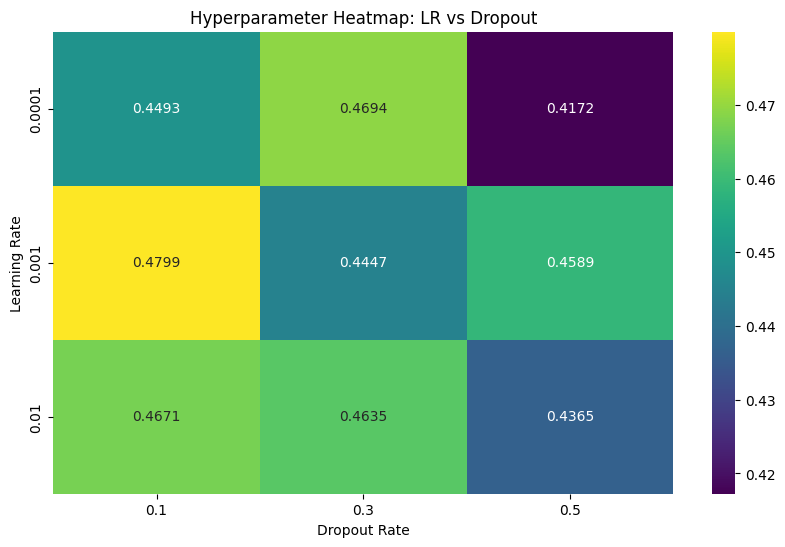

/var/folders/x0/v0fp040j50l8mg8fgqc931zc0000gn/T/ipykernel_14125/277745305.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=hp, y='best_val_dice', data=viz_df, order=unique_vals, palette='Set2')


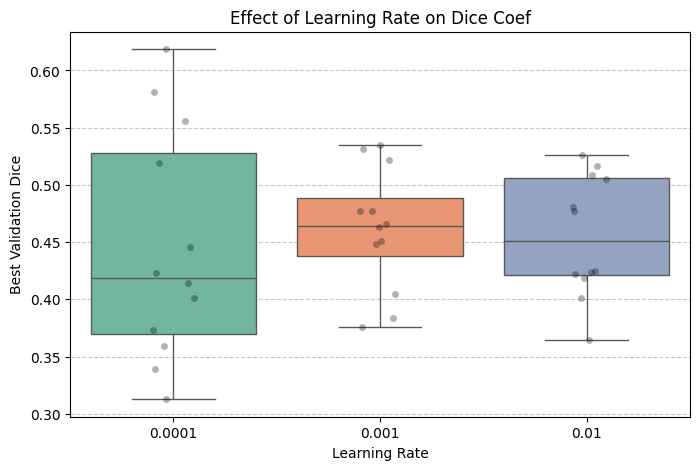

/var/folders/x0/v0fp040j50l8mg8fgqc931zc0000gn/T/ipykernel_14125/277745305.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=hp, y='best_val_dice', data=viz_df, order=unique_vals, palette='Set2')


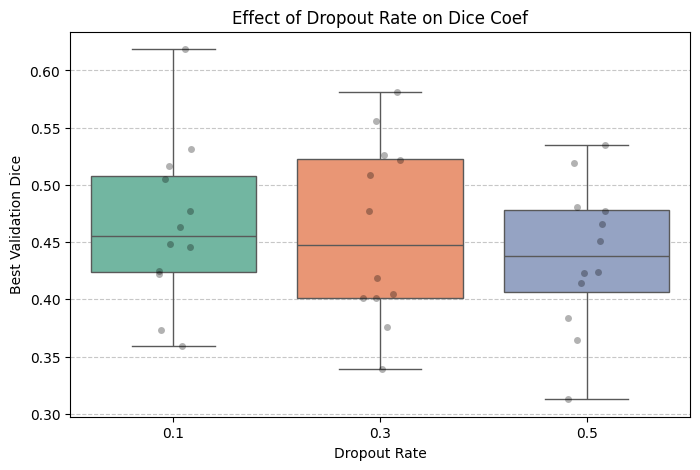

/var/folders/x0/v0fp040j50l8mg8fgqc931zc0000gn/T/ipykernel_14125/277745305.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=hp, y='best_val_dice', data=viz_df, order=unique_vals, palette='Set2')


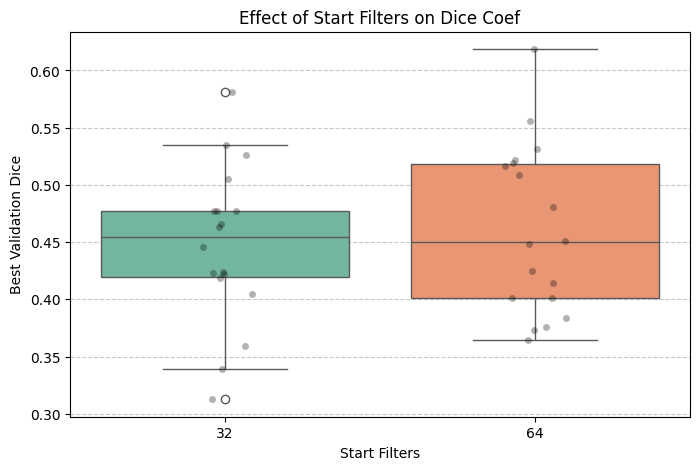

/var/folders/x0/v0fp040j50l8mg8fgqc931zc0000gn/T/ipykernel_14125/277745305.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=hp, y='best_val_dice', data=viz_df, order=unique_vals, palette='Set2')


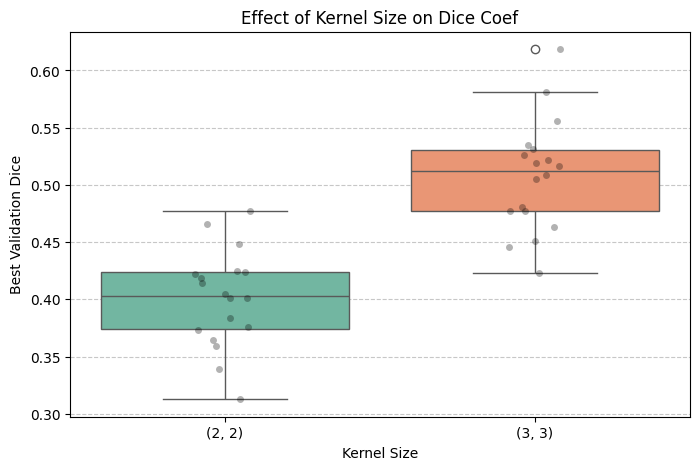

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a copy for visualization to avoid modifying the original data
viz_df = df_search.copy()

# 1. Convert hyperparameter columns to strings to prevent plotting errors with tuples/objects
# This ensures that (2, 2) becomes "(2, 2)"
plot_cols = ['learning_rate', 'dropout_rate', 'gamma', 'start_filters', 'kernel_size', 'pooling_type']
for col in plot_cols:
    if col in viz_df.columns:
        viz_df[col] = viz_df[col].astype(str)

# 2. General Heatmap (Learning Rate vs Dropout)
# We aggregate by mean in case there are multiple runs for the same pair
pivot = viz_df.pivot_table(index='learning_rate', columns='dropout_rate', values='best_val_dice', aggfunc='mean')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, cmap='viridis', fmt=".4f")
plt.title('Hyperparameter Heatmap: LR vs Dropout')
plt.ylabel('Learning Rate')
plt.xlabel('Dropout Rate')
plt.show()

# 3. Individual Effect Plots
for hp in plot_cols:
    # Only plot if there is variation (more than 1 unique value)
    if hp in viz_df.columns and viz_df[hp].nunique() > 1:
        plt.figure(figsize=(8, 5))
        
        # Sort the x-axis categories so the plot is readable (e.g., 0.1, 0.3, 0.5)
        # We try to sort numerically if possible, otherwise alphabetically
        unique_vals = sorted(viz_df[hp].unique(), key=lambda x: (float(x) if x.replace('.','',1).isdigit() else x))
        
        sns.boxplot(x=hp, y='best_val_dice', data=viz_df, order=unique_vals, palette='Set2')
        sns.stripplot(x=hp, y='best_val_dice', data=viz_df, order=unique_vals, color='black', alpha=0.3)
        
        plt.title(f'Effect of {hp.replace("_", " ").title()} on Dice Coef')
        plt.xlabel(hp.replace("_", " ").title())
        plt.ylabel('Best Validation Dice')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()

### 4. Final Model Training
Training the "winner" configuration for 50 epochs until convergence.


In [8]:
import ast

# Extract values from best_run
best_lr = float(best_run['learning_rate'])
best_dropout = float(best_run['dropout_rate'])
best_gamma = float(best_run['gamma'])
best_filters = int(best_run['start_filters'])
best_pooling = best_run['pooling_type']

# FIX: Convert the string representation of the tuple back into an actual tuple
if isinstance(best_run['kernel_size'], str):
    best_kernel = ast.literal_eval(best_run['kernel_size'])
else:
    best_kernel = best_run['kernel_size']

print(f"\nTraining Output Model...")

K.clear_session()
final_model = build_custom_unet(
    start_filters=best_filters, 
    kernel_size=best_kernel, 
    dropout_rate=best_dropout,
    pooling_type=best_pooling
)
final_model.compile(optimizer=tf.keras.optimizers.Adam(best_lr),
                    loss=focal_loss(gamma=best_gamma),
                    metrics=[dice_coef, iou_coef, 'accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')])

callbacks = [
    ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_dice_coef', mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
]

history = final_model.fit(train_ds, validation_data=val_ds, epochs=50, callbacks=callbacks, verbose=1)


Training Output Model...
Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8489 - dice_coef: 0.3263 - iou_coef: 0.1972 - loss: 0.0529 - precision: 0.5507 - recall: 0.4274
Epoch 1: val_dice_coef improved from None to 0.20198, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.9023 - dice_coef: 0.3855 - iou_coef: 0.2411 - loss: 0.0316 - precision: 0.7451 - recall: 0.4992 - val_accuracy: 0.8591 - val_dice_coef: 0.2020 - val_iou_coef: 0.1126 - val_loss: 0.0702 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9448 - dice_coef: 0.4923 - iou_coef: 0.3275 - loss: 0.0138 - precision: 0.9493 - recall: 0.6572
Epoch 2: val_dice_coef did not improve from 0.20198
72/72 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.9547 - dice_coef: 0.5276 - iou_coef: 0.3599 - loss: 0.0120 - precision: 0.9523 - recall: 0.

### 5. Final Evaluation

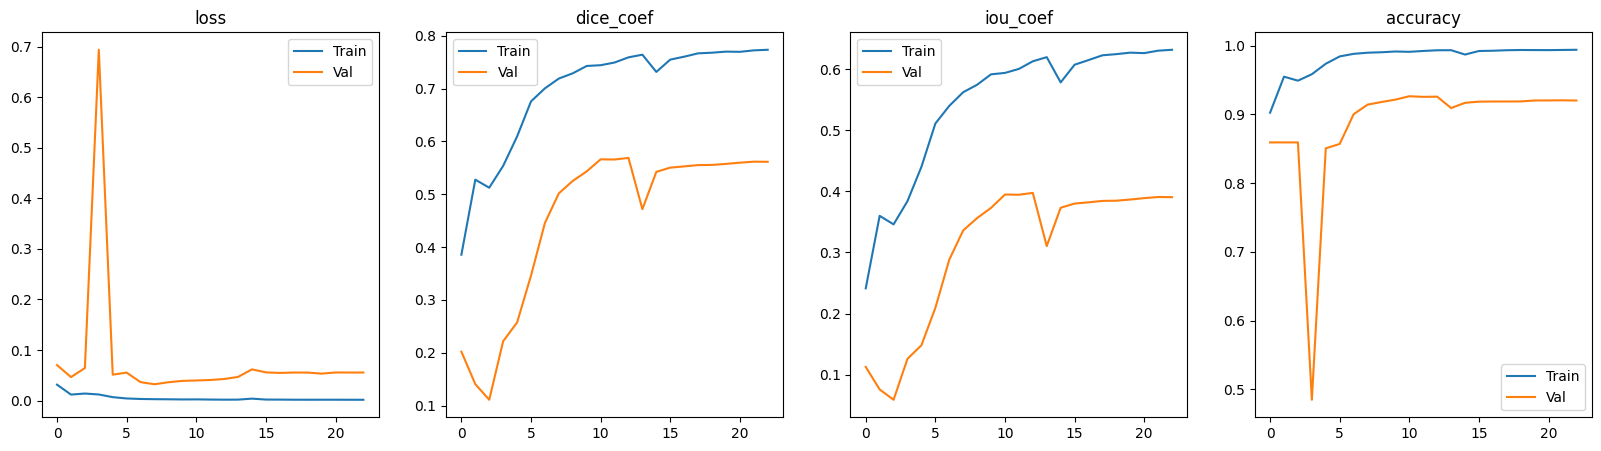

Visualizing Best Model Predictions...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step


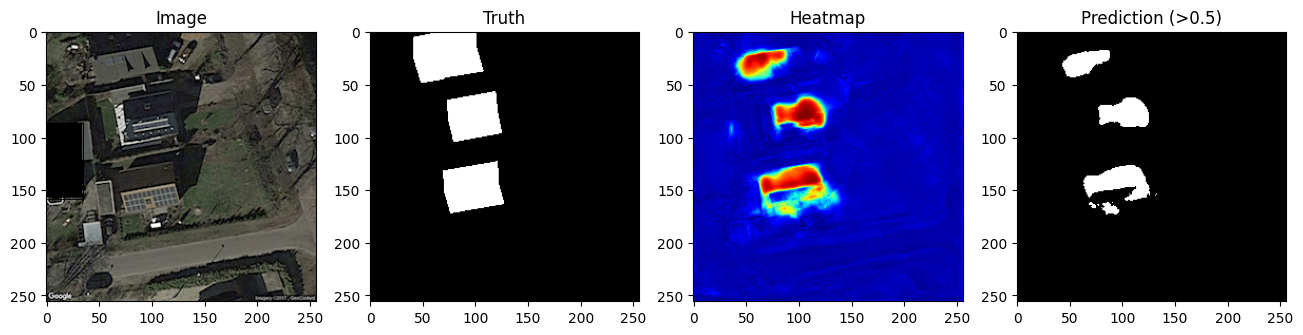

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step


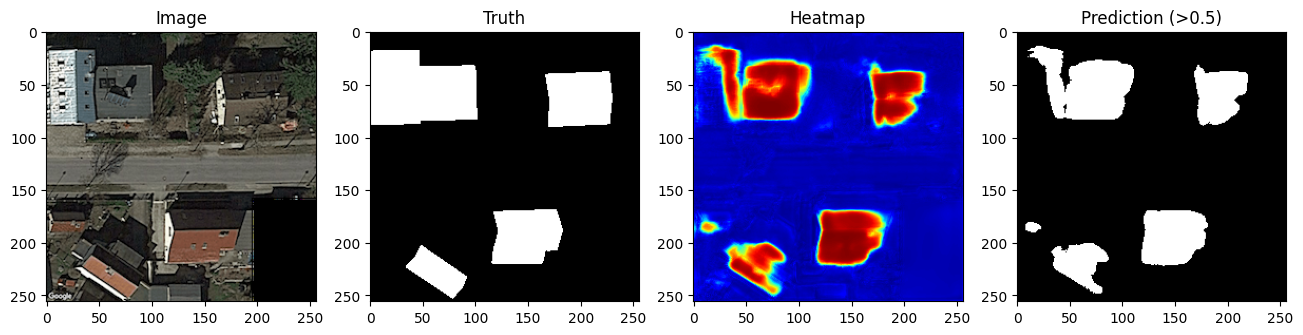

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


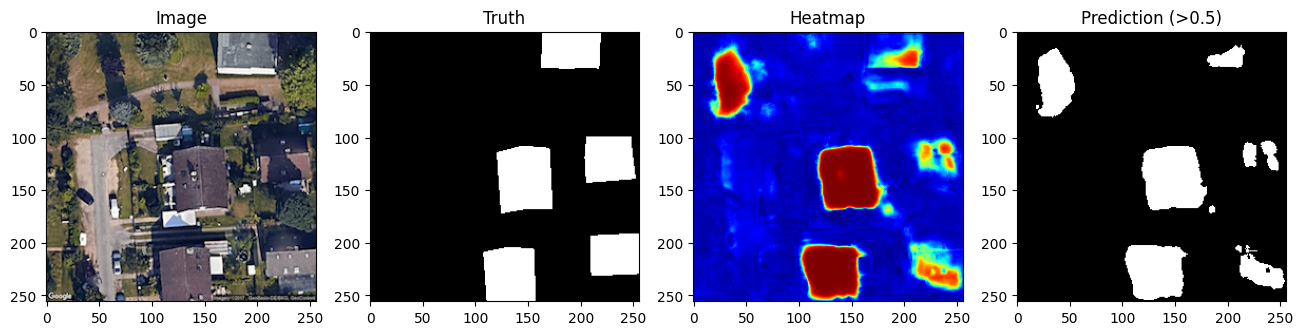

2026-01-13 15:59:08.137872: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [9]:
def plot_metrics(history):
    metrics = ['loss', 'dice_coef', 'iou_coef', 'accuracy']
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    for i, metric in enumerate(metrics):
        if metric in history.history:
            axes[i].plot(history.history[metric], label='Train')
            axes[i].plot(history.history[f'val_{metric}'], label='Val')
            axes[i].set_title(metric)
            axes[i].legend()
    plt.show()

plot_metrics(history)

print("Visualizing Best Model Predictions...")
best_model_loaded = tf.keras.models.load_model('best_model.keras', custom_objects={'focal_loss_fixed': focal_loss(gamma=2.0), 'dice_coef': dice_coef, 'iou_coef': iou_coef})

for img, mask in val_ds.unbatch().take(3):
    pred = best_model_loaded.predict(np.expand_dims(img, axis=0))[0]
    pred_mask = (pred > 0.5).astype(np.float32)
    
    fig, ax = plt.subplots(1, 4, figsize=(16, 4))
    ax[0].imshow(img)
    ax[0].set_title("Image")
    ax[1].imshow(mask, cmap='gray')
    ax[1].set_title("Truth")
    ax[2].imshow(pred, cmap='jet')
    ax[2].set_title("Heatmap")
    ax[3].imshow(pred_mask, cmap='gray')
    ax[3].set_title("Prediction (>0.5)")
    plt.show()

### 6. to_test

Loading best model for inference...
Testing on 5 images...


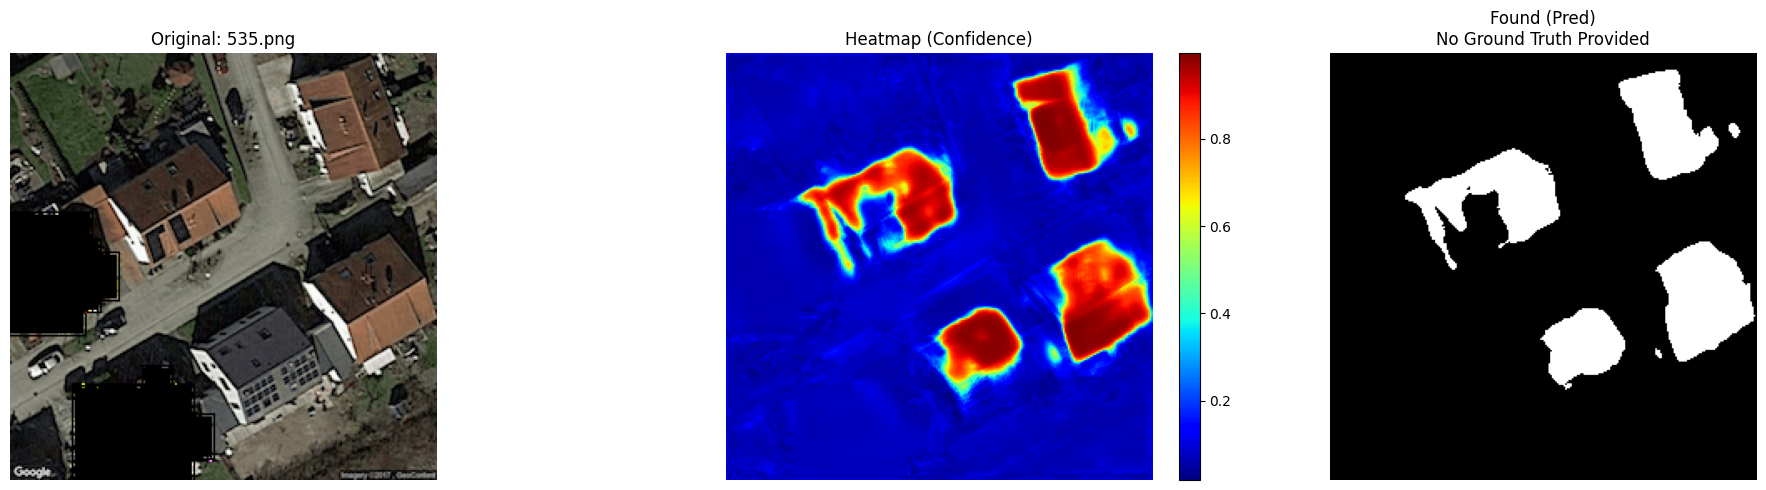

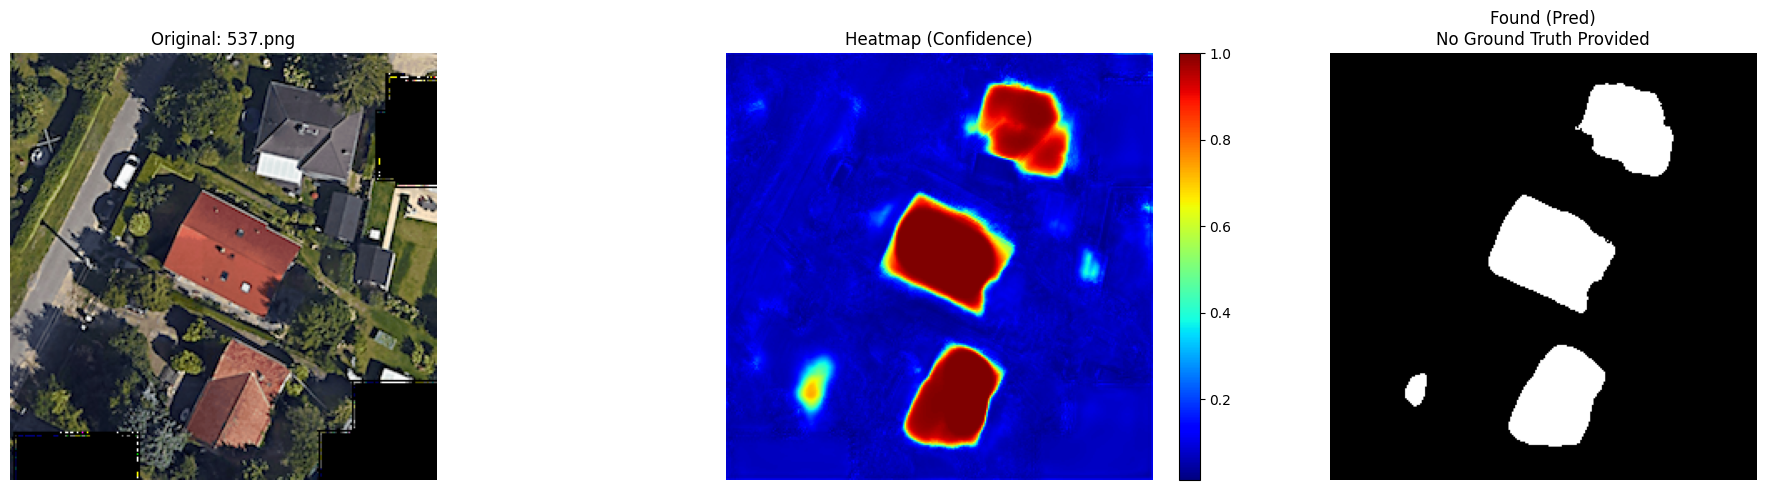

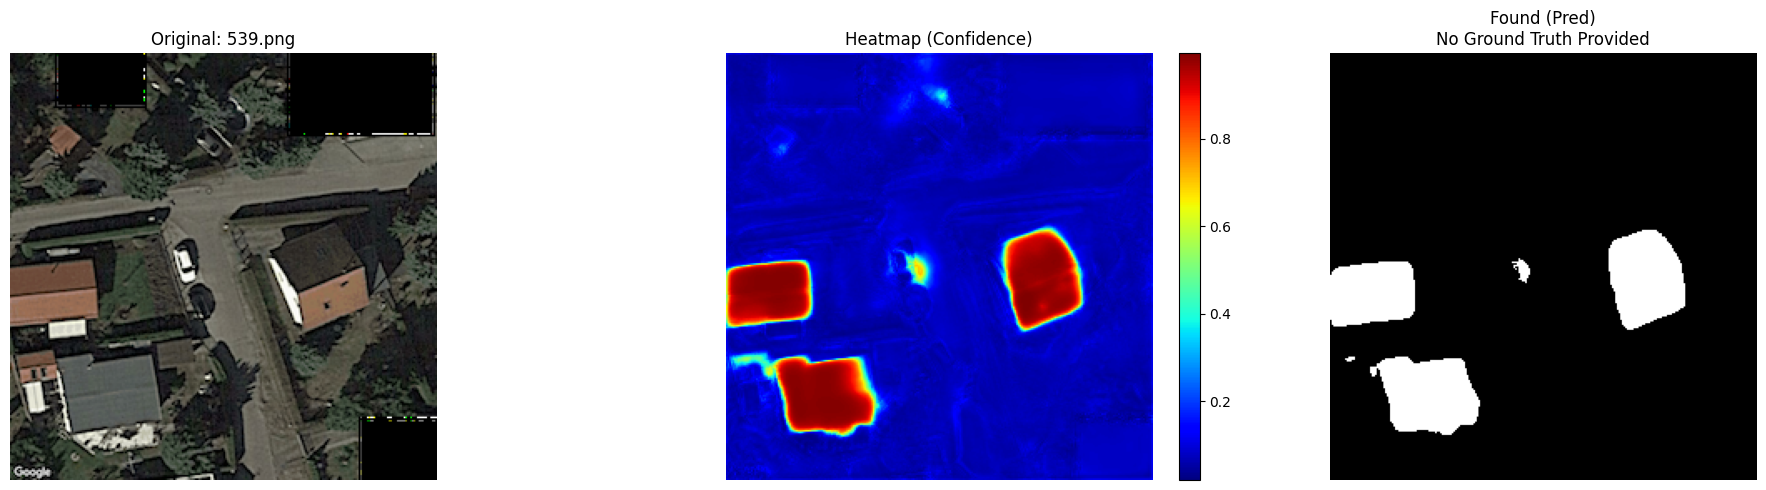

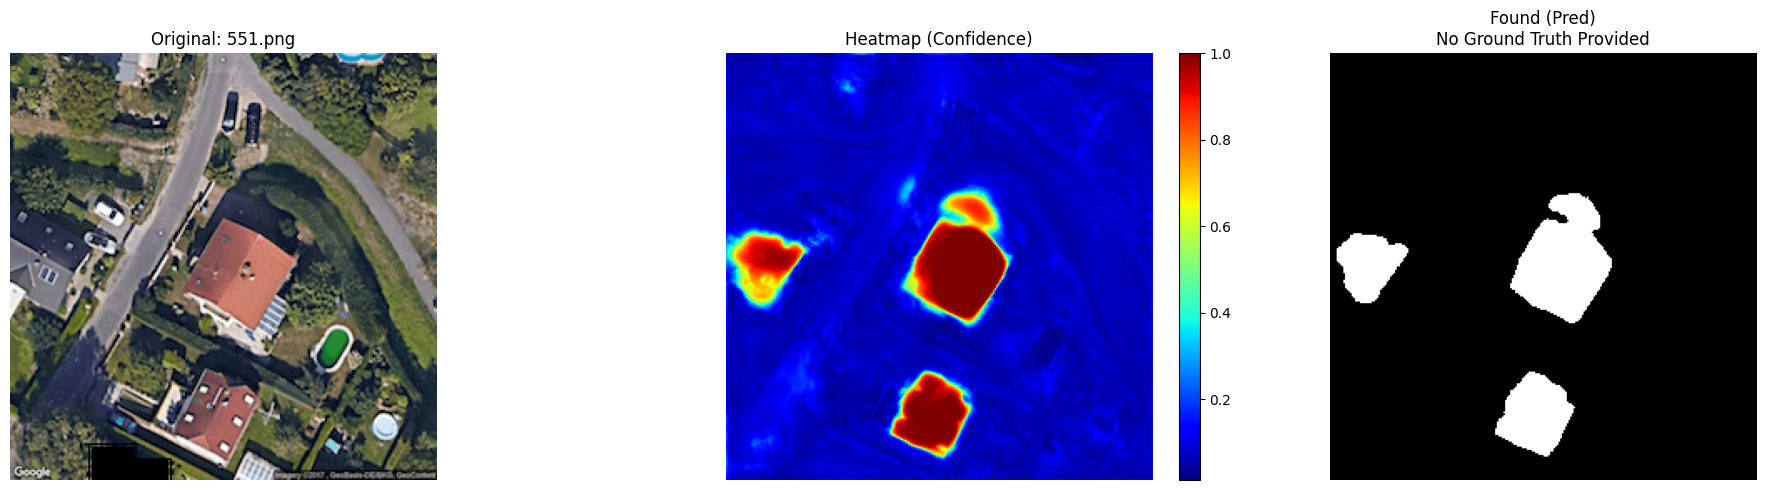

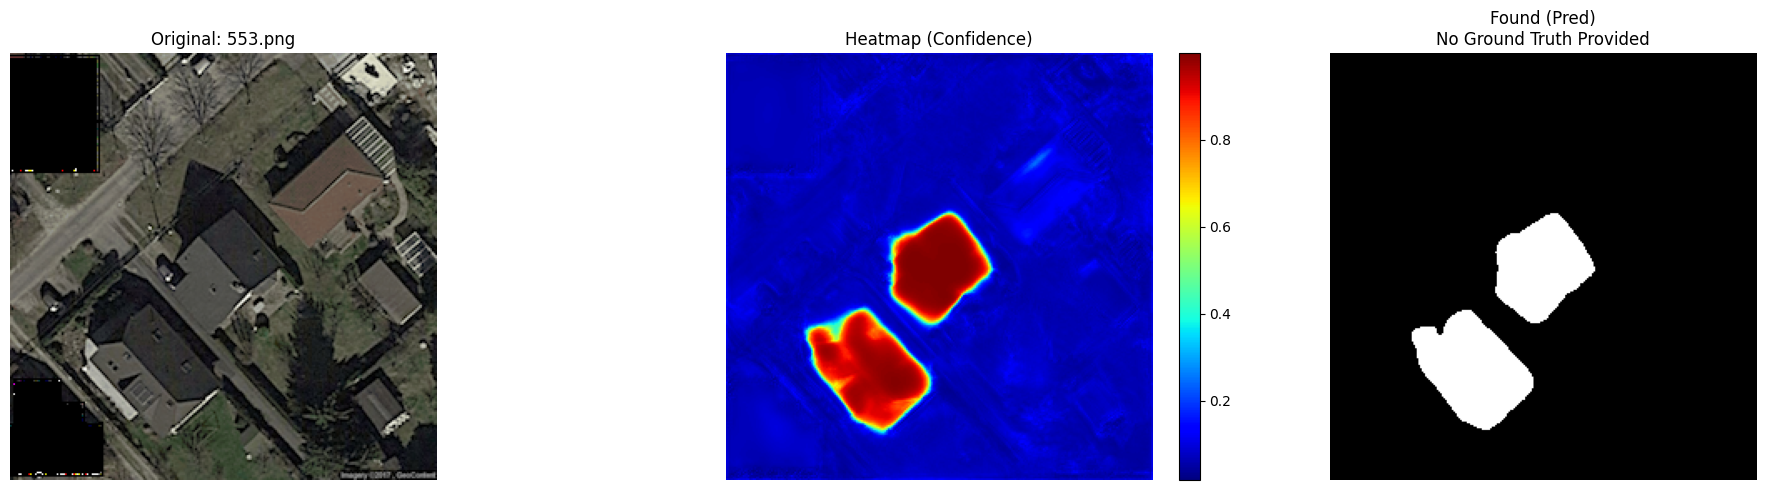

In [10]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# 1. Configuration for Testing
TEST_IMG_DIR = "/Users/dc/Desktop/GSU/Pers - Gonenc Hoca - Deep Learning/Final/to-test/"
# Optional: Set this to your test labels directory if you have them
TEST_MASK_DIR = None # Change to "to_test_labels/" if available

def load_and_preprocess(path, is_mask=False):
    if is_mask:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        img = (img > 127).astype(np.float32) # Binarize
        return np.expand_dims(img, axis=-1)
    else:
        img = cv2.imread(path, cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        return img.astype(np.float32) / 255.0

# 2. Load the best saved model
# Note: Ensure custom objects match your build_custom_unet setup
print("Loading best model for inference...")
model_path = 'best_model.keras'
best_model = tf.keras.models.load_model(model_path, custom_objects={
    'focal_loss_fixed': focal_loss(), 
    'dice_coef': dice_coef, 
    'iou_coef': iou_coef
})

# 3. Get list of images
test_files = sorted([f for f in os.listdir(TEST_IMG_DIR) if f.endswith(('.png', '.jpg', '.jpeg'))])

# 4. Visualization and Metric Loop
print(f"Testing on {len(test_files)} images...")

for filename in test_files:
    img_path = os.path.join(TEST_IMG_DIR, filename)
    img = load_and_preprocess(img_path)
    
    # Predict
    pred_raw = best_model.predict(np.expand_dims(img, axis=0), verbose=0)[0]
    pred_mask = (pred_raw > 0.5).astype(np.float32)
    
    # Calculate metrics if ground truth is available
    metrics_text = "No Ground Truth Provided"
    has_truth = False
    
    if TEST_MASK_DIR and os.path.exists(os.path.join(TEST_MASK_DIR, filename)):
        truth = load_and_preprocess(os.path.join(TEST_MASK_DIR, filename), is_mask=True)
        iou = iou_coef(tf.cast(truth, tf.float32), tf.cast(pred_mask, tf.float32)).numpy()
        dice = dice_coef(tf.cast(truth, tf.float32), tf.cast(pred_mask, tf.float32)).numpy()
        metrics_text = f"IoU: {iou:.4f} | Dice: {dice:.4f}"
        has_truth = True

    # Display Table-like visualization
    num_cols = 4 if has_truth else 3
    fig, axes = plt.subplots(1, num_cols, figsize=(20, 5))
    
    # Original
    axes[0].imshow(img)
    axes[0].set_title(f"Original: {filename}")
    axes[0].axis('off')
    
    current_idx = 1
    # Expected (if available)
    if has_truth:
        axes[current_idx].imshow(truth.squeeze(), cmap='gray')
        axes[current_idx].set_title("Expected (Truth)")
        axes[current_idx].axis('off')
        current_idx += 1
        
    # Heatmap
    im_heat = axes[current_idx].imshow(pred_raw.squeeze(), cmap='jet')
    axes[current_idx].set_title("Heatmap (Confidence)")
    plt.colorbar(im_heat, ax=axes[current_idx], fraction=0.046, pad=0.04)
    axes[current_idx].axis('off')
    current_idx += 1
    
    # Found (Thresholded)
    axes[current_idx].imshow(pred_mask.squeeze(), cmap='gray')
    axes[current_idx].set_title(f"Found (Pred)\n{metrics_text}")
    axes[current_idx].axis('off')
    
    plt.tight_layout()
    plt.show()

## 7. Areas of Improvement & Future Work

While the current implementation provides a solid foundation for aerial semantic segmentation, several avenues for further enhancement exist to increase the model's robustness and generalization capabilities.

### 7.1. Implementation of k-Fold Cross-Validation

The most significant limitation of the current study is the small size of the dataset. Currently, a single train-test split is used, which might lead to performance metrics that are sensitive to the specific samples in the validation set.

* **Proposed Solution:** Implementing **k-Fold Cross-Validation** would allow the model to be trained and validated on  different subsets of the data. This provides a more robust estimate of the model's true performance and ensures that the hyperparameter optimization results are not biased by a "lucky" data split.

### 7.2. Comparison with Transfer Learning Baselines

This project intentionally focused on a fully custom CNN architecture to master the underlying theory. However, for a production-level benchmark:

* **Proposed Solution:** Comparing the custom architecture against pre-trained backbones (e.g., **ResNet50** or **EfficientNet** encoders) would help quantify the efficiency of the custom feature extraction layers.

### 7.3. Advanced Architectural Modules

To improve the segmentation of fine details (such as thin roads or small buildings) in aerial images:

* **Proposed Solution:** Integrating **Attention Gates** (Attention U-Net) or **Residual Blocks** (ResU-Net) could help the network focus on relevant spatial features while mitigating the vanishing gradient problem in deeper layers.

### 7.4. Bayesian Optimization for Hyperparameters

While the **Grid Search** provided a systematic overview, it is computationally expensive and limited to predefined discrete values.

* **Proposed Solution:** Utilizing **Bayesian Optimization** would allow for a more intelligent, non-linear search of the hyperparameter space, potentially finding "fine-tuned" values between the current grid steps.

### 7.5. Synthetic Data and GANs

Given the difficulty of obtaining labeled aerial imagery:

* **Proposed Solution:** Exploring **Generative Adversarial Networks (GANs)** to generate synthetic aerial tiles could augment the training set significantly, improving the model's ability to generalize to different geographic regions or lighting conditions.

